In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("Chocolate Sales (2).csv")

In [32]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [33]:
df.shape

(3282, 6)

In [34]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [35]:
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [36]:
##removing $, from amount
df['Amount'] = df['Amount'].replace('[\$,]' , '' , regex=True).astype(float)
df['Amount']

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\hp\AppData\Local\Temp\ipykernel_27460\3354050901.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]' , '' , regex=True).astype(float)


0        5320.00
1        7896.00
2        4501.00
3       12726.00
4       13685.00
          ...   
3277     5303.58
3278     7339.32
3279      616.09
3280     2504.62
3281     5915.87
Name: Amount, Length: 3282, dtype: float64

In [37]:
df['Date'] = pd.to_datetime(df['Date'] , dayfirst=True)

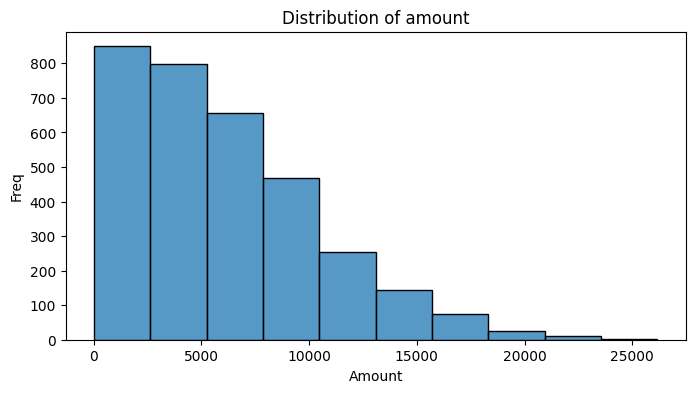

In [38]:
#histogram
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'] , bins=10)
plt.title('Distribution of amount')
plt.ylabel('Freq')
plt.show()

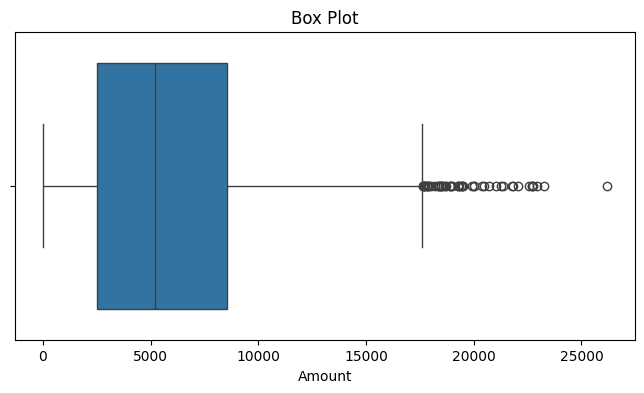

In [39]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount'])
plt.title('Box Plot')
plt.show()

<Axes: xlabel='Country', ylabel='count'>

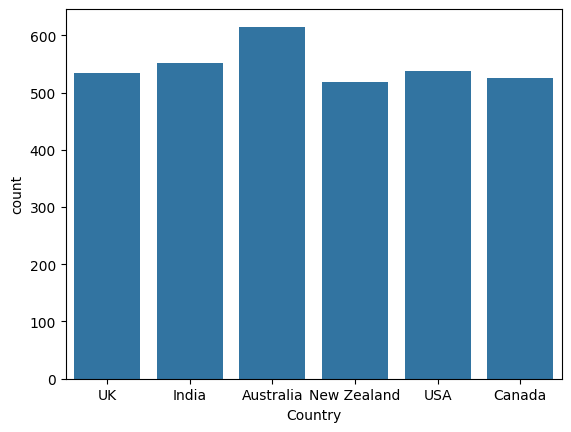

In [40]:
sns.countplot(x=df['Country'])

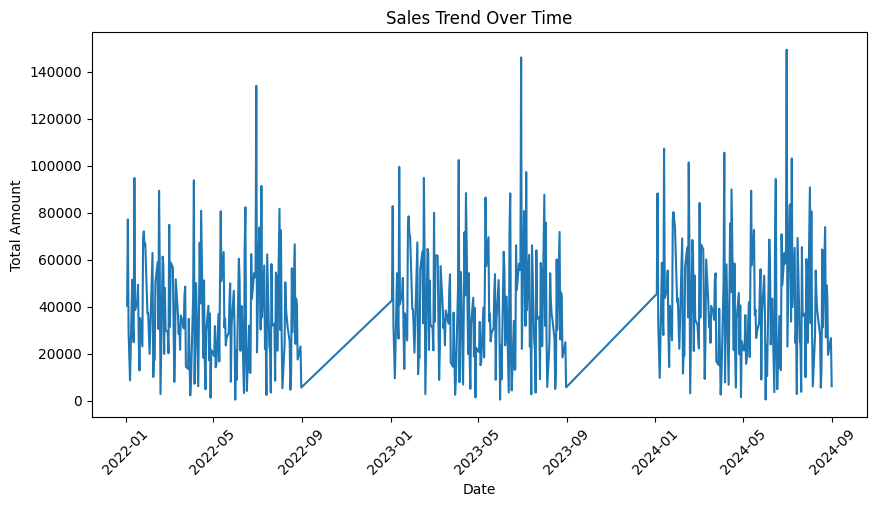

In [41]:
plt.figure(figsize=(10, 5))
daily_sales = df.groupby('Date')['Amount'].sum().sort_index()
sns.lineplot(x=daily_sales.index, y=daily_sales.values)
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

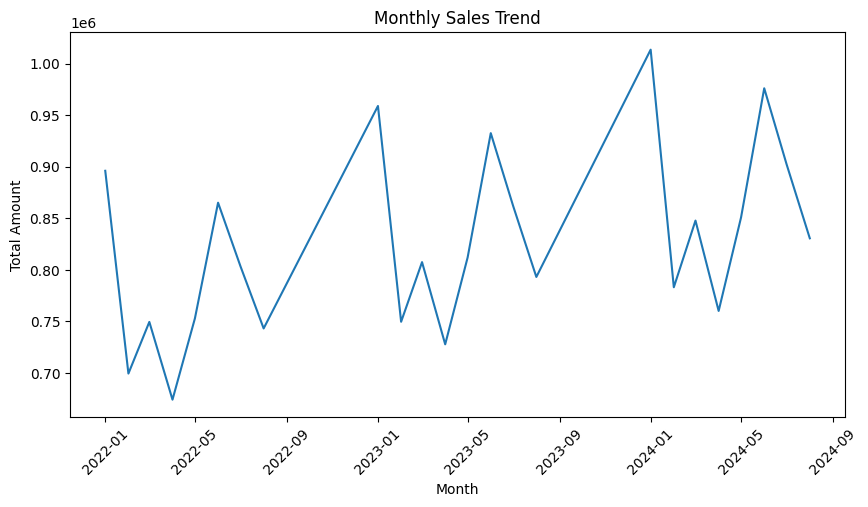

In [42]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

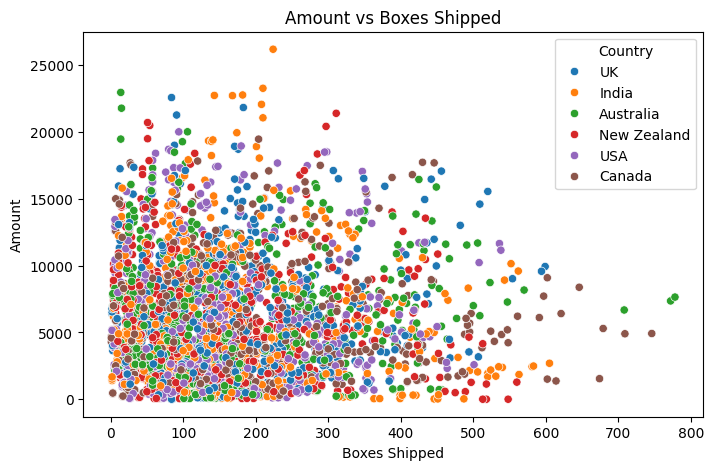

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Boxes Shipped', y='Amount', hue='Country')
plt.title('Amount vs Boxes Shipped')
plt.xlabel('Boxes Shipped')
plt.ylabel('Amount')
plt.show()

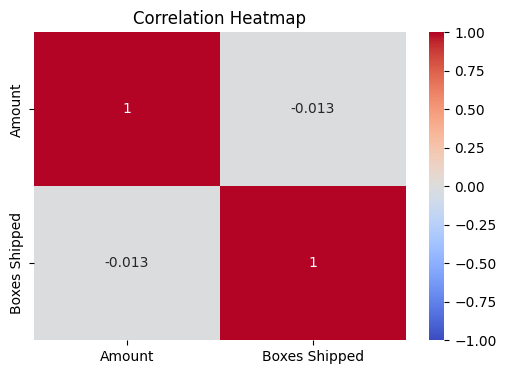

In [44]:
plt.figure(figsize=(6, 4))
corr = df[['Amount', 'Boxes Shipped']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


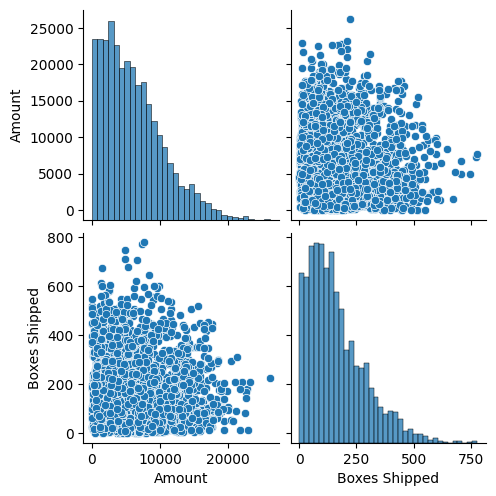

In [45]:
sns.pairplot(df)

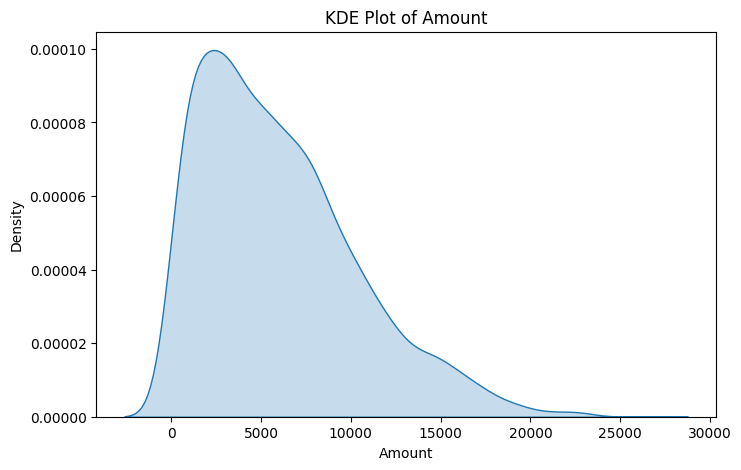

In [46]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['Amount'], fill=True)
plt.title('KDE Plot of Amount')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.show()

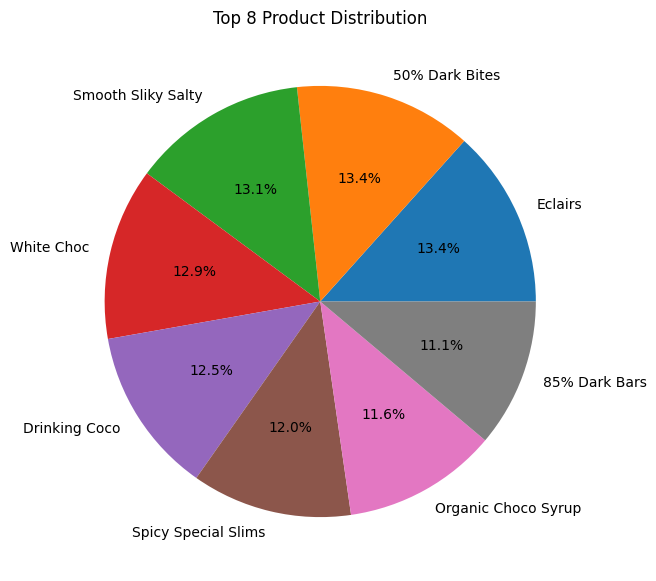

In [47]:
product_counts = df['Product'].value_counts().head(8)

plt.figure(figsize=(7,7))
product_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 8 Product Distribution')
plt.ylabel('')
plt.show()